# E-Commerce Profit Leakage Analyzer

In [6]:
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio.templates.default = "plotly_white"

In [7]:
data = pd.read_csv("Sample - Superstore.csv" , encoding = 'latin-1')

In [8]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Converting date columns

In [13]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [16]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year
data['Order Day Of Week'] = data['Order Date'].dt.dayofweek

In [23]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Month', 'Order Year', 'Order Day Of Week'],
      dtype='object')

In [18]:
data['Order Date'].dtype

dtype('<M8[ns]')

In [19]:
print(data.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [24]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day Of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6


## Monthly Sales Analysis

In [25]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()


In [26]:
sales_by_month

,Order Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


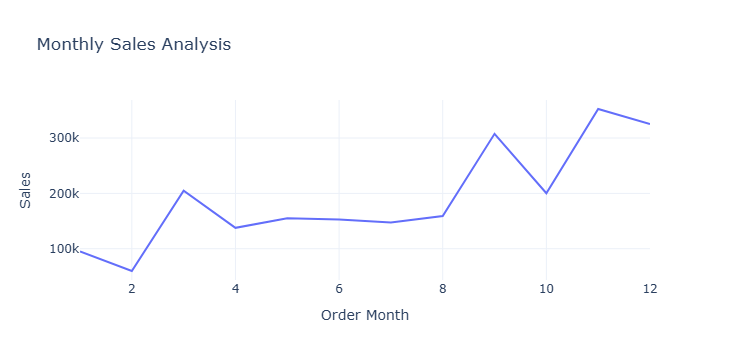

In [28]:
sales_by_month = data.groupby('Order Month')['Sales'].sum().reset_index()
fig = px.line(sales_by_month,
              x='Order Month',
              y='Sales',
              title='Monthly Sales Analysis')
fig.show()

## Sales By Category

In [29]:
sales_by_category = data.groupby('Category')['Sales'].sum().reset_index()

In [30]:
sales_by_category

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


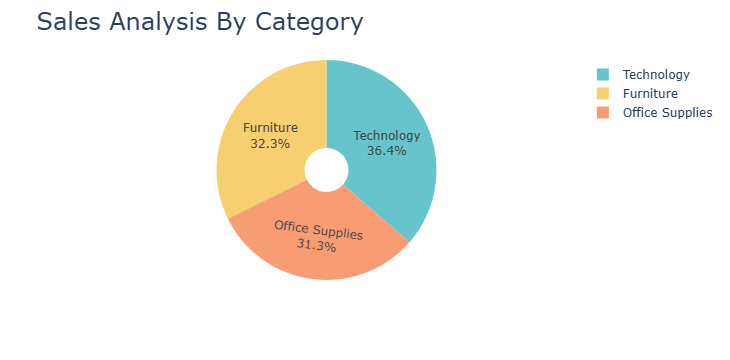

In [32]:
fig = px.pie(sales_by_category,
             values='Sales',
             names='Category',
             hole=0.2,
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textposition='inside', textinfo= 'percent+label')
fig.update_layout(title_text='Sales Analysis By Category',title_font=dict(size=24))

fig.show()

## Sales Analysis By Subcategory

In [33]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day Of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6


In [34]:
sales_by_subcategory = data.groupby('Sub-Category')['Sales'].sum().reset_index()

In [35]:
sales_by_subcategory

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


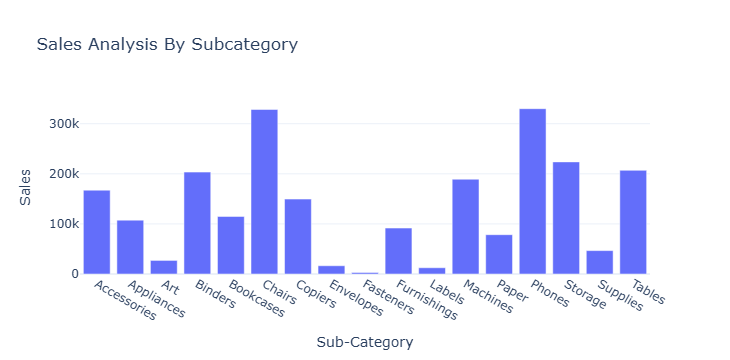

In [40]:
fig= px.bar(sales_by_subcategory,
            x= 'Sub-Category',
            y= 'Sales',
            title= "Sales Analysis By Subcategory")
fig.show()

## Monthly Profit Analysis

In [41]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day Of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6


In [43]:
profit_by_month = data.groupby('Order Month')['Profit'].sum().reset_index()

In [44]:
profit_by_month 

,Order Month,Profit
0,1,9134.4461
1,2,10294.6107
2,3,28594.6872
3,4,11587.4363
4,5,22411.3078
5,6,21285.7954
6,7,13832.6648
7,8,21776.9384
8,9,36857.4753
9,10,31784.0413


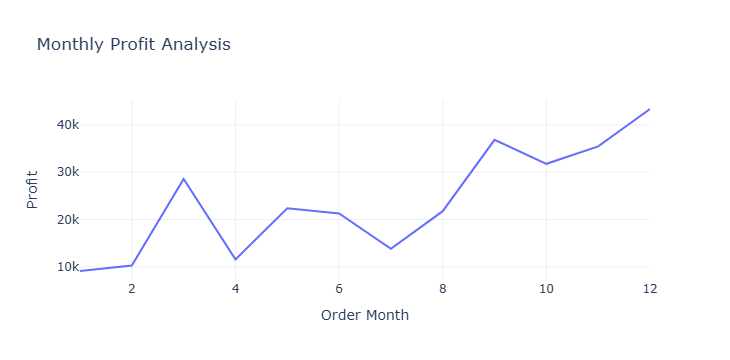

In [45]:
fig = px.line(profit_by_month,
              x='Order Month',
              y='Profit',
              title='Monthly Profit Analysis')
fig.show()

## Analyzing Profit By Category

In [47]:
profit_by_category =data.groupby('Category')['Profit'].sum().reset_index()

In [48]:
profit_by_category

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


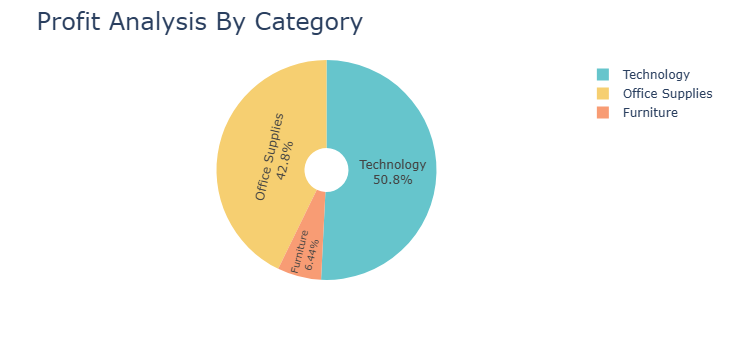

In [49]:
fig = px.pie(profit_by_category,
             values='Profit',
             names='Category',
             hole=0.2,
             color_discrete_sequence=px.colors.qualitative.Pastel)

fig.update_traces(textposition='inside', textinfo= 'percent+label')
fig.update_layout(title_text='Profit Analysis By Category',title_font=dict(size=24))

fig.show()

## Analysing Profit By Subcategory

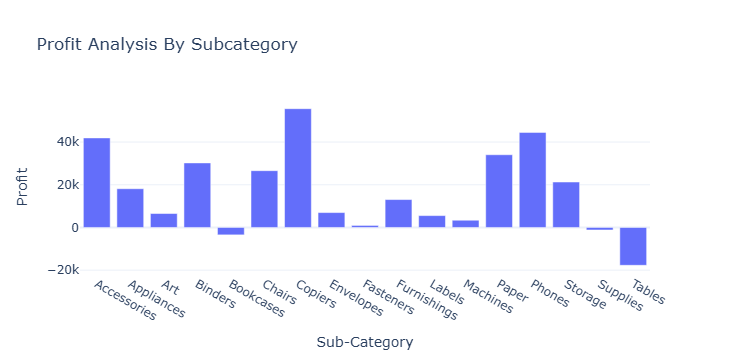

In [51]:
profit_by_subcategory =data.groupby('Sub-Category')['Profit'].sum().reset_index()
fig= px.bar(profit_by_subcategory,
            x= 'Sub-Category',
            y= 'Profit',
            title= "Profit Analysis By Subcategory")
fig.show()

## Sales And Profit - Customer Segment

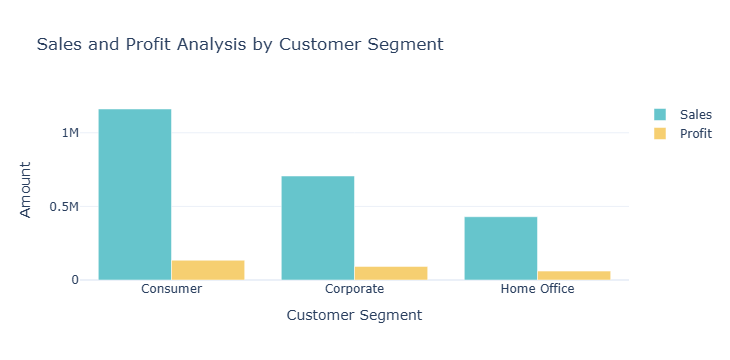

In [54]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales':'sum','Profit':'sum'}).reset_index()

color_palette = colors.qualitative.Pastel


fig = go.Figure()
fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'],
                     y=sales_profit_by_segment['Sales'],
                     name='Sales',
                     marker_color=color_palette[0]))

fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'],
                     y=sales_profit_by_segment['Profit'],
                     name='Profit',
                     marker_color=color_palette[1]))

fig.update_layout(title='Sales and Profit Analysis by Customer Segment',
                  xaxis_title= 'Customer Segment', yaxis_title='Amount')

fig.show()
              

## Analysing Sales To Profit ratio

In [55]:
sales_profit_by_segment = data.groupby('Segment').agg({'Sales':'sum','Profit':'sum'}).reset_index()
sales_profit_by_segment['Sales_to_Profit_Ratio']= sales_profit_by_segment['Sales']/sales_profit_by_segment['Profit']
print(sales_profit_by_segment[['Segment','Sales_to_Profit_Ratio']])

       Segment  Sales_to_Profit_Ratio
0     Consumer               8.659471
1    Corporate               7.677245
2  Home Office               7.125416


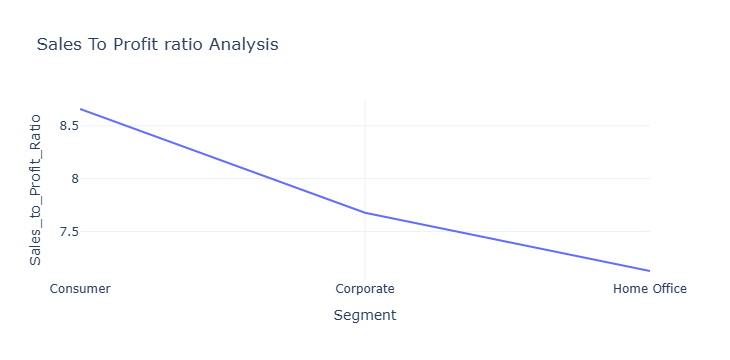

In [56]:
fig = px.line(sales_profit_by_segment,
              x='Segment',
              y='Sales_to_Profit_Ratio',
              title='Sales To Profit ratio Analysis')
fig.show()

# Profit Leakage Analysis

In [1]:
print("jupyter is working")

jupyter is working


In [10]:
print (data.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [9]:
who

colors	 data	 dataframe_columns	 dataframe_hash	 dtypes_str	 get_dataframes	 getpass	 go	 hashlib	 
import_pandas_safely	 is_data_frame	 json	 pd	 pio	 px	 


## Top 10 Loss Making Products

In [11]:
loss_products = (
    data.groupby("Product Name")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


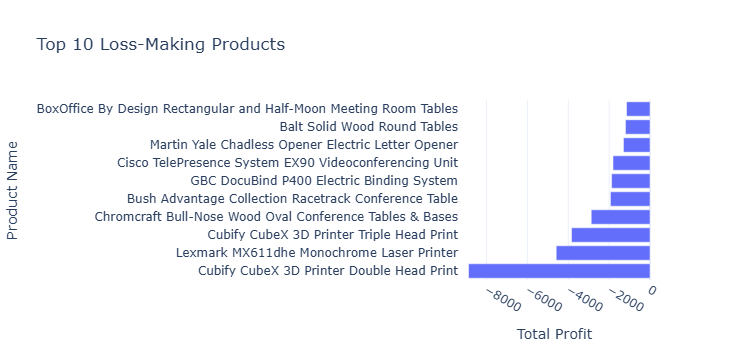

In [12]:
fig = px.bar(
    x=loss_products.values,
    y=loss_products.index,
    orientation="h",
    title="Top 10 Loss-Making Products",
    labels={
        "x":"Total Profit",
        "y":"Product Name"
    }
)

fig.show()

### Business Insight

The analysis reveals that a small group of products contributes disproportionately to overall losses.

Potential reasons:

- Excessive discounting
- High procurement costs
- Low profit margins
- Poor pricing strategy

Management should review these products and consider pricing, sourcing or discontinuation strategies.

## Loss Making Subcategories Analysis

In [21]:
loss_subcategory = (data.groupby("Sub-Category")["Profit"].sum().sort_values())

print(loss_subcategory.head(10))

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64


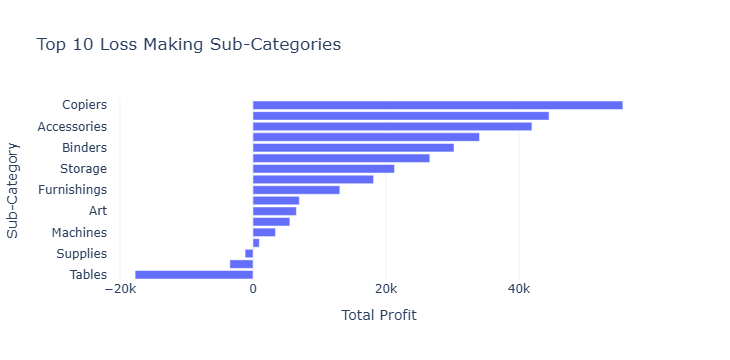

In [27]:
fig = px.bar(
    x=loss_subcategory.values,
    y=loss_subcategory.index,
    orientation='h',
    title='Top 10 Loss Making Sub-Categories',
    labels={
        'x':'Total Profit',
        'y':'Sub-Category'
    }
)

fig.show()

### Business Insight

Certain sub-categories consistently generate losses despite contributing to sales.

Possible causes:

- Aggressive discounting
- High logistics costs
- Low pricing efficiency

These sub-categories should be reviewed to improve overall profitability.

## Discount Impact Analysis

In [32]:
discount_analysis = data.groupby("Category").agg({
    "Discount":"mean",
    "Profit":"sum"
}).reset_index()

print(discount_analysis)

          Category  Discount       Profit
0        Furniture  0.173923   18451.2728
1  Office Supplies  0.157285  122490.8008
2       Technology  0.132323  145454.9481


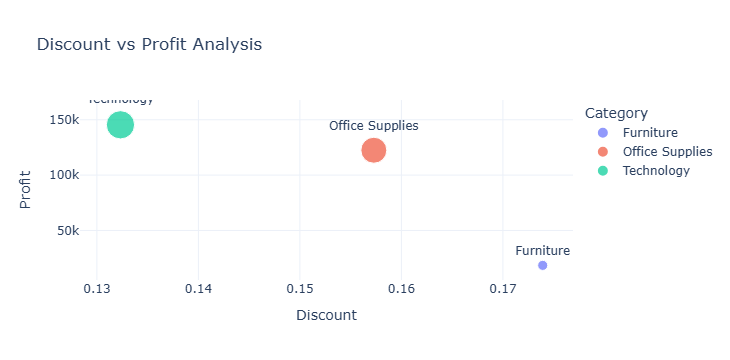

In [35]:
fig = px.scatter(
    discount_analysis,
    x="Discount",
    y="Profit",
    size="Profit",
    color="Category",
    text="Category",
    title="Discount vs Profit Analysis"
)

fig.update_traces(textposition="top center")

fig.show()

### Business Insight
Furniture has the highest discount but generates the lowest profit.
Technology has the lowest discount but generates the highest profit.

Recommendation:
- Review Furniture pricing strategy 
- Reduce excessive discounting
- Focus on high-margin Technology products

# Regional Profitability Dashboard

In [36]:
region_profit = (data.groupby("Region")["Profit"].sum().reset_index())

print(region_profit)

    Region       Profit
0  Central   39706.3625
1     East   91522.7800
2    South   46749.4303
3     West  108418.4489


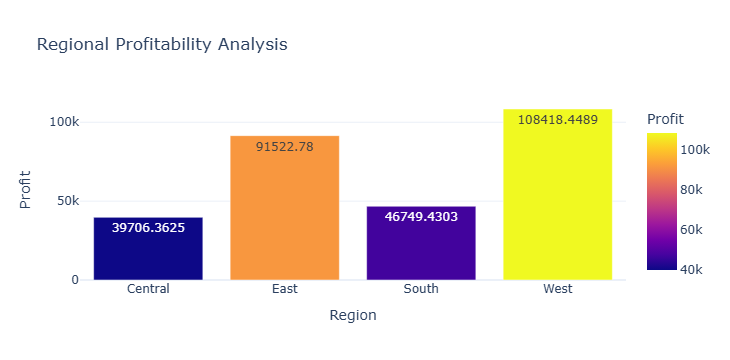

In [37]:
fig = px.bar(region_profit,
    x="Region",
    y="Profit",
    color="Profit",
    text="Profit",
    title="Regional Profitability Analysis"
)

fig.show()

## Business Insight

Regional profit distribution highlights, which geographical markets contribute most to company profitability.

Recommendations:
- Increase investment in high-performing regions.
- Investigate causes of lower profitability regions.
- Optimize marketing and logistics strategy region-wise.

## Executive KPI Dashboard

In [41]:
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_orders = data["Order ID"].nunique()
profit_margin = (total_profit / total_sales) * 100

best_category = (
    data.groupby("Category")["Profit"]
        .sum()
        .idxmax()
)

best_region = (
    data.groupby("Region")["Profit"]
        .sum()
        .idxmax()
)

print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Profit Margin:", round(profit_margin,2),"%")
print("Total Orders:", total_orders)
print("Best Category:", best_category)
print("Best Region:", best_region)

Total Sales: 2297200.86
Total Profit: 286397.02
Profit Margin: 12.47 %
Total Orders: 5009
Best Category: Technology
Best Region: West


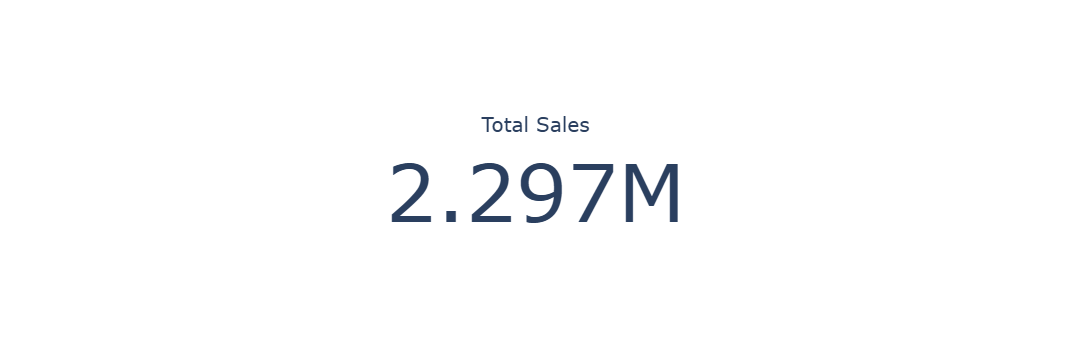

In [42]:
fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_sales,
    title={"text":"Total Sales"}
))

fig.show()

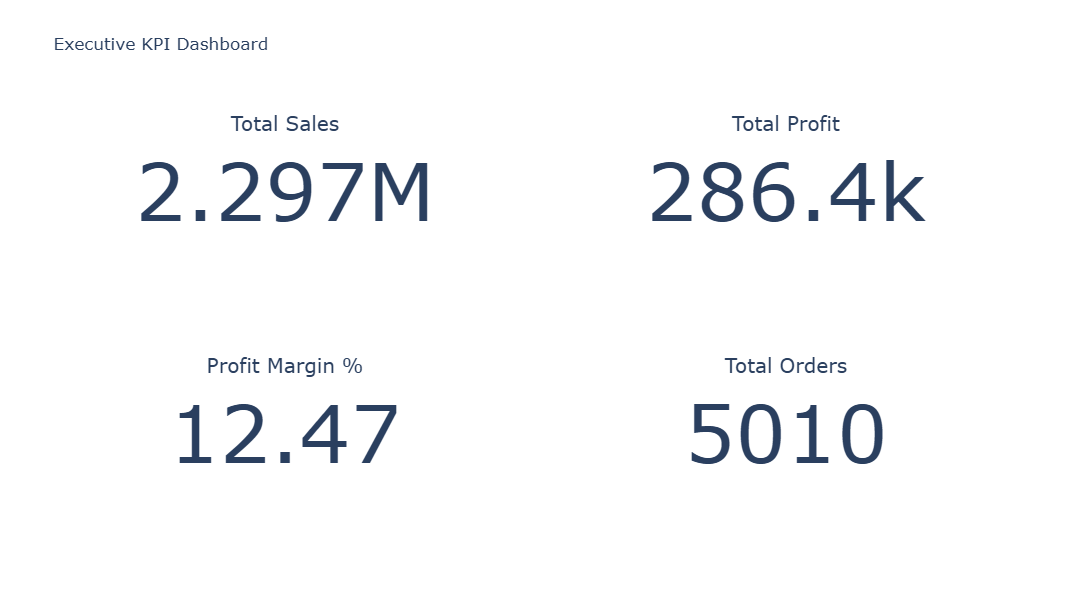

In [43]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type":"indicator"},{"type":"indicator"}],
           [{"type":"indicator"},{"type":"indicator"}]]
)

fig.add_trace(
    go.Indicator(mode="number",
                 value=total_sales,
                 title={"text":"Total Sales"}),
    row=1,col=1
)

fig.add_trace(
    go.Indicator(mode="number",
                 value=total_profit,
                 title={"text":"Total Profit"}),
    row=1,col=2
)

fig.add_trace(
    go.Indicator(mode="number",
                 value=profit_margin,
                 title={"text":"Profit Margin %"}),
    row=2,col=1
)

fig.add_trace(
    go.Indicator(mode="number",
                 value=total_orders,
                 title={"text":"Total Orders"}),
    row=2,col=2
)

fig.update_layout(
    height=600,
    title_text="Executive KPI Dashboard"
)

fig.show()

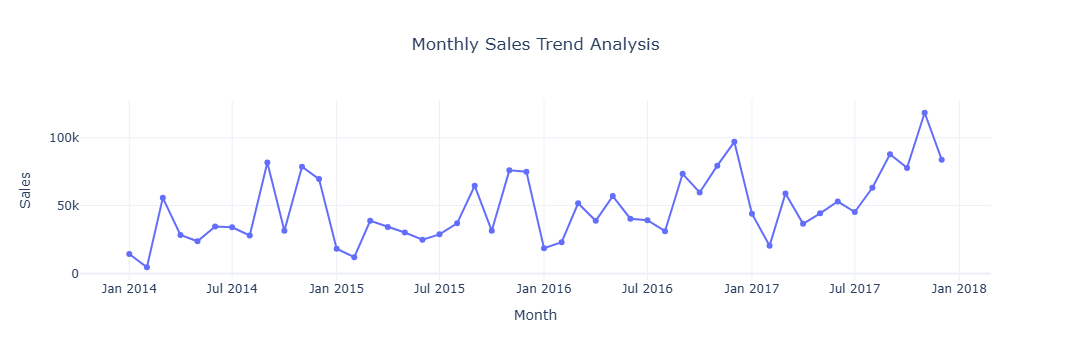

In [44]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

monthly_sales = data.groupby(
    data['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

fig = px.line(
    x=monthly_sales.index,
    y=monthly_sales.values,
    title='Monthly Sales Trend Analysis',
    labels={
        'x':'Month',
        'y':'Sales'
    },
    markers=True
)

fig.update_layout(
    title_x=0.5
)

fig.show()

### Business Insight
- Sales are generally increasing over time
- Strong spikes during some months (seasonality)
- Business growth from 2014 → 2017

## Top Customers Analysis

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


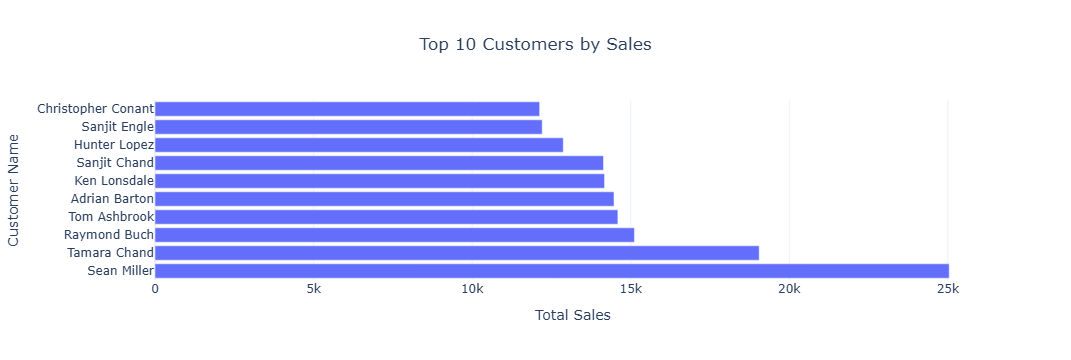

In [45]:
top_customers = (data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10))

print(top_customers)

fig = px.bar(
    x=top_customers.values,
    y=top_customers.index,
    orientation='h',
    title='Top 10 Customers by Sales',
    labels={
        'x':'Total Sales',
        'y':'Customer Name'
    }
)

fig.update_layout(title_x=0.5)

fig.show()

### Business Insight

A small group of customers contributes significantly to overall sales.

Recommendations

- Strengthen relationships with top customers.
- Offer loyalty programs and premium support.
- Develop retention strategies to maximize customer lifetime value.

## Customer Segmentation (RFM Analysis)

#### creating RFM table

In [46]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

snapshot_date = data['Order Date'].max() + pd.Timedelta(days=1)

rfm = data.groupby('Customer Name').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer Name,,,
Aaron Bergman,416,3,886.156
Aaron Hawkins,13,7,1744.700
Aaron Smayling,89,7,3050.692
Adam Bellavance,55,8,7755.620
Adam Hart,35,10,3250.337


#### Creating customer scores

In [47]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer Name,,,,,,,
Aaron Bergman,416,3,886.156,1,1,1,111
Aaron Hawkins,13,7,1744.700,4,3,2,432
Aaron Smayling,89,7,3050.692,2,3,3,233
Adam Bellavance,55,8,7755.620,3,3,4,334
Adam Hart,35,10,3250.337,3,4,3,343


#### Identifying best customers

In [48]:
champions = rfm[
    (rfm['R_Score'].astype(int) >= 3) &
    (rfm['F_Score'].astype(int) >= 3) &
    (rfm['M_Score'].astype(int) >= 3)
]

print("Champion Customers")
print(champions.head(10))

Champion Customers
                    Recency  Frequency   Monetary R_Score F_Score M_Score  \
Customer Name                                                               
Adam Bellavance          55          8   7755.620       3       3       4   
Adam Hart                35         10   3250.337       3       4       3   
Adam Shillingsburg       29          9   3255.310       4       4       3   
Adrian Barton            42         10  14473.571       3       4       4   
Alan Dominguez           30          8   6106.880       4       3       4   
Alan Hwang                7          9   4805.344       4       4       4   
Amy Cox                  12          7   5527.846       4       3       4   
Annie Thurman            14         10   3831.864       4       4       4   
Anthony Jacobs           76          7   4867.344       3       3       4   
Anthony Rawles           59          8   4523.336       3       3       4   

                   RFM_Score  
Customer Name            

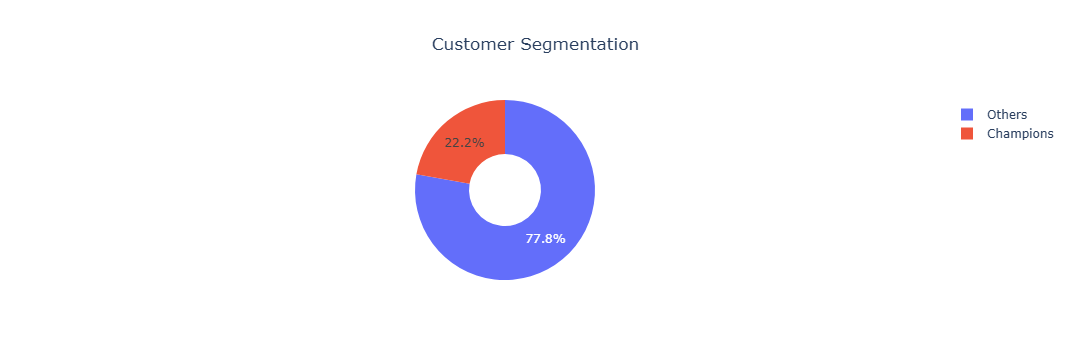

In [49]:
segment_counts = {
    "Champions": len(champions),
    "Others": len(rfm) - len(champions)
}

fig = px.pie(
    values=list(segment_counts.values()),
    names=list(segment_counts.keys()),
    hole=0.4,
    title="Customer Segmentation"
)

fig.update_layout(title_x=0.5)

fig.show()

## Business Insight

Champion customers generate a significant share of revenue and should be prioritized for retention.

Recommendations

- Offer exclusive rewards and loyalty benefits.
- Develop personalized marketing campaigns.
- Increase engagement with high-value customers.

## Sales Forecasting 

In [51]:
monthly_sales_forecast = (
    data.groupby(
        data['Order Date'].dt.to_period('M')
    )['Sales']
    .sum()
    .reset_index()
)

monthly_sales_forecast['Order Date'] = (
    monthly_sales_forecast['Order Date']
    .astype(str)
)

monthly_sales_forecast.head()

,Order Date,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


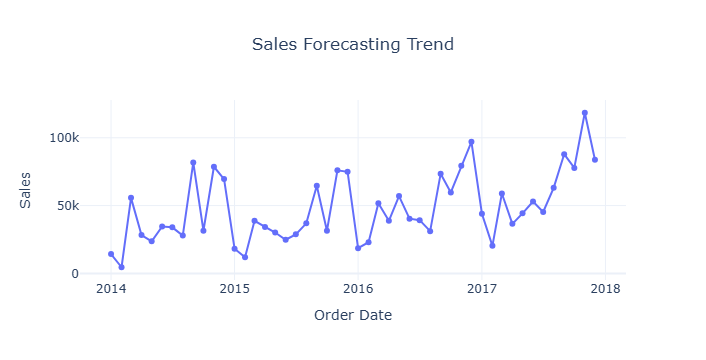

In [52]:
fig = px.line(monthly_sales_forecast,
    x='Order Date',
    y='Sales',
    title='Sales Forecasting Trend',
    markers=True
)

fig.update_layout(title_x=0.5)

fig.show()

## Business Insight

Historical sales trends indicate overall business growth with periodic seasonal fluctuations.

 Recommendations

- Prepare inventory before peak sales periods.
- Increase marketing spend during high-growth months.
- Forecast demand to optimize supply chain planning.